In [3]:
import pandas as pd
import numpy as np

In [4]:
def get_individual(season):
    df_individual = pd.read_csv(f"/Users/lionlucky7/Desktop/MLB/data/{season}/hitters_individual.csv")
    df_individual = df_individual.iloc[:, 1:]
    
    df_obp_individual = df_individual[["id", "current_team", "obp", "plateAppearances"]]

    df_obp_individual['weight_obp'] = df_obp_individual.obp * df_obp_individual.plateAppearances    
    
    team_weighted_sum = df_obp_individual.groupby('current_team')['weight_obp'].sum()
    team_pa_sum = df_obp_individual.groupby("current_team")['plateAppearances'].sum()
    team_obp_weighted = team_weighted_sum / team_pa_sum


    df_team_obp_weighted = pd.DataFrame(data=team_obp_weighted, columns=["weighted_obp"])
    df_team_obp_weighted.index.name = "TEAM"
    
    mlb_teams = [
        "Baltimore Orioles", "Boston Red Sox", "New York Yankees", "Tampa Bay Rays", "Toronto Blue Jays",
        "Chicago White Sox", "Cleveland Guardians", "Detroit Tigers", "Kansas City Royals", "Minnesota Twins",
        "Houston Astros", "Los Angeles Angels", "Oakland Athletics", "Seattle Mariners", "Texas Rangers",
        "Atlanta Braves", "Miami Marlins", "New York Mets", "Philadelphia Phillies", "Washington Nationals",
        "Chicago Cubs", "Cincinnati Reds", "Milwaukee Brewers", "Pittsburgh Pirates", "St. Louis Cardinals",
        "Arizona Diamondbacks", "Colorado Rockies", "Los Angeles Dodgers", "San Diego Padres", "San Francisco Giants"
    ]

    df_team_obp_weighted = df_team_obp_weighted.rename(index = {"Athletics": "Oakland Athletics"})

    df_team_obp_weighted = df_team_obp_weighted[df_team_obp_weighted.index.isin(mlb_teams)]
    
    df_team = pd.read_csv(f"/Users/lionlucky7/Desktop/MLB/data/{season}/team_stats.csv")
    df_team = df_team.drop(['Unnamed: 0'], axis=1)
    df_team_obp = df_team[['TEAM', "OBP"]]
    
    df_team_obp = df_team_obp.sort_values("TEAM", ascending=False)
    df_team_obp_weighted = df_team_obp_weighted.sort_index(ascending=False)

    df_team_obp = df_team_obp.set_index("TEAM")
    
    if list(df_team_obp.index) == list(df_team_obp_weighted.index):
        print("They have the same list")

    df_standings = pd.read_csv(f"/Users/lionlucky7/Desktop/MLB/data/{season}/team_standings.csv")
    df_standings = df_standings[['TEAM', "win_rate"]]
    df_standings = df_standings.set_index("TEAM").sort_values("TEAM", ascending=False)

    if df_standings.index.equals(df_team_obp.index):
        print("They have the same index")
    

    df_combined = pd.concat([df_team_obp, df_team_obp_weighted, df_standings], axis=1)
    
    return df_combined

# Result

In [5]:
total_data = pd.DataFrame()
for season in range(2024, 2013, -1):
    df_temp = get_individual(season)
    total_data = pd.concat([total_data, df_temp], axis=0)

They have the same list
They have the same index
They have the same list
They have the same index
They have the same list
They have the same index
They have the same index
They have the same index
They have the same index
They have the same index
They have the same index
They have the same index
They have the same index
They have the same index


/var/folders/0_/_3dg0b615p38ptjrygv5db6h0000gn/T/ipykernel_29629/2496119483.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_obp_individual['weight_obp'] = df_obp_individual.obp * df_obp_individual.plateAppearances
/var/folders/0_/_3dg0b615p38ptjrygv5db6h0000gn/T/ipykernel_29629/2496119483.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_obp_individual['weight_obp'] = df_obp_individual.obp * df_obp_individual.plateAppearances
/var/folders/0_/_3dg0b615p38ptjrygv5db6h0000gn/T/ipykernel_29629/24961

In [6]:
total_data

,OBP,weighted_obp,win_rate
TEAM,,,
Washington Nationals,0.309,0.304112,0.438272
Toronto Blue Jays,0.313,0.307348,0.456790
Texas Rangers,0.305,0.310706,0.481481
Tampa Bay Rays,0.302,0.301175,0.493827
St. Louis Cardinals,0.312,0.312765,0.512346
...,...,...,...
Boston Red Sox,0.316,NaN,0.438272
Baltimore Orioles,0.311,NaN,0.592593
Atlanta Braves,0.305,0.330305,0.487654


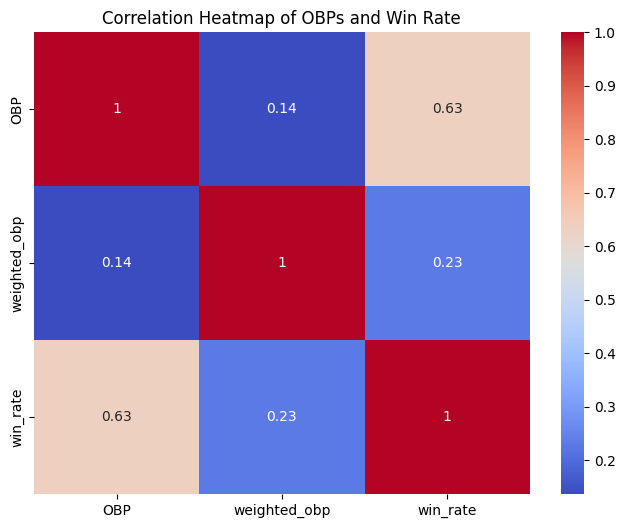

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cor = total_data.corr()

plt.figure(figsize=(8, 6))  
sns.heatmap(cor, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of OBPs and Win Rate")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')  # PNG format, high resolution

plt.show()

# Others

## Others

## Individual

In [ ]:
df_individual = pd.read_csv("/Users/lionlucky7/Desktop/MLB/data/hitters_individual.csv")

In [ ]:
df_individual = df_individual.iloc[:, 1:]
pd.set_option('display.max_columns', None)

df_individual.drop(["mlb_debut", "type", "group", "bat_side", "pitch_hand", "season", "age"], axis=1, inplace=True)

In [ ]:
df_obp_individual = df_individual[["id", "current_team", "obp", "plateAppearances"]]

df_obp_individual['weight_obp'] = df_obp_individual.obp * df_obp_individual.plateAppearances

In [ ]:
team_weighted_sum = df_obp_individual.groupby('current_team')['weight_obp'].sum()
team_pa_sum = df_obp_individual.groupby("current_team")['plateAppearances'].sum()
team_obp_weighted = team_weighted_sum / team_pa_sum

df_team_obp_weighted = pd.DataFrame(data=team_obp_weighted, columns=["weighted_obp"])

mlb_teams = [
    "Baltimore Orioles", "Boston Red Sox", "New York Yankees", "Tampa Bay Rays", "Toronto Blue Jays",
    "Chicago White Sox", "Cleveland Guardians", "Detroit Tigers", "Kansas City Royals", "Minnesota Twins",
    "Houston Astros", "Los Angeles Angels", "Oakland Athletics", "Seattle Mariners", "Texas Rangers",
    "Atlanta Braves", "Miami Marlins", "New York Mets", "Philadelphia Phillies", "Washington Nationals",
    "Chicago Cubs", "Cincinnati Reds", "Milwaukee Brewers", "Pittsburgh Pirates", "St. Louis Cardinals",
    "Arizona Diamondbacks", "Colorado Rockies", "Los Angeles Dodgers", "San Diego Padres", "San Francisco Giants"
]

df_team_obp_weighted = df_team_obp_weighted.rename(index = {"Athletics": "Oakland Athletics"})

df_team_obp_weighted = df_team_obp_weighted[df_team_obp_weighted.index.isin(mlb_teams)]

## Team Stats

In [ ]:
df_team = pd.read_csv("/Users/lionlucky7/Desktop/MLB/data/team_stats.csv")
df_team = df_team.drop(['Unnamed: 0'], axis=1)
df_team_obp = df_team[['TEAM', "OBP"]]

## Comparing

In [ ]:
df_team_obp = df_team_obp.sort_values("TEAM", ascending=False)
df_team_obp_weighted = df_team_obp_weighted.sort_values("current_team", ascending=False)

df_team_obp = df_team_obp.set_index("TEAM")

In [ ]:
if list(df_team_obp.index) == list(df_team_obp_weighted.index):
    print("They have the same list")

# Checking if they have the same dataset


In [ ]:
df_combined = pd.concat([df_team_obp, df_team_obp_weighted], axis=1)

In [ ]:
df_combined['difference'] = abs(df_combined.OBP - df_combined.weighted_obp)

In [ ]:
df_combined['percent_difference'] = df_combined.difference / df_combined.weighted_obp * 100

## Team Standings

In [ ]:
df_standings = pd.read_csv("/Users/lionlucky7/Desktop/MLB/data/team_standings.csv")
df_standings = df_standings[['TEAM', "win_rate"]]
df_standings = df_standings.set_index("TEAM").sort_values("TEAM", ascending=False)

if df_standings.index.equals(df_combined.index):
    print("They have the same index")

## Final

In [ ]:
df_final = pd.concat([df_combined, df_standings], axis=1)

correlation = df_final.corr()

## Correlation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(width, height))  # width and height in inches
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.show()